# Preprocesiranje podataka

**Koraci:** izvedeni atributi, čišćenje podataka, transformacija vrednosti atributa, standardizacija, smanjenje dimenzionalnosti i izbor podskupa atributa

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from collections import Counter

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from theme import *

In [2]:
Path("../plots/preprocessing").mkdir(parents=True, exist_ok=True)
Path("../models").mkdir(parents=True, exist_ok=True) # cuvamo istrenirane modele koje ce klasifikator samo da učita

Učitavanje originalnog skupa podataka

In [3]:
df = pd.read_csv("../data/trees.csv")

## 1. Izvedeni atributi

**`odd/even_depth_chance_count`**: AB pravi grešku na CHANCE čvorovima na dva načina u zavisnosti od parnosti dubine: neparne dubine (1, 3, 5...) potcenjuju optimalnu putanju, parne (2, 4, 6...) je precenjuju

**`tree_difficulty`**: koliko je stablo teško za algoritme uopšte: easy (oba tačna), medium (jedan tačan), hard (nijedan tačan)

In [4]:
odd = sum(df[f"chance_node_count_d{d}"] for d in range(1, 16, 2))
even = sum(df[f"chance_node_count_d{d}"] for d in range(2, 16, 2))

df = df.copy()
df["odd_depth_chance_count"] = odd
df["even_depth_chance_count"] = even

df[["odd_depth_chance_count", "even_depth_chance_count"]].describe().transpose().round(1)

,count,mean,std,min,25%,50%,75%,max
odd_depth_chance_count,5016.0,1331.3,1818.5,0.0,139.8,638.0,1646.8,10796.0
even_depth_chance_count,5016.0,1786.1,2985.8,0.0,111.0,532.0,2352.8,21560.0


In [5]:
difficulty_map = {"Both": "easy", "AB": "medium", "MCTS": "medium", "Neither": "hard"}
df["tree_difficulty"] = df["which_algo"].map(difficulty_map)

df["tree_difficulty"].value_counts().reindex(["easy", "medium", "hard"])

tree_difficulty
easy      1109
medium    1785
hard      2122
Name: count, dtype: int64

## 2. Čišćenje podataka

### 2.1 Nedostajuće vrednosti

Provereno u EDA (01_eda.ipynb): dataset nema nedostajućih vrednosti

### 2.2 Detekcija autlajera

IQR metoda: vrednosti ispod `Q1 - 1.5*IQR` ili iznad `Q3 + 1.5*IQR`

In [6]:
outlier_cols = [
    "total_nodes", "leaf_value_std", "best_move_margin",
    "ab_pruning_rate", "mcts_vote_margin", "exact_root_eval_std"
]

rows = []
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum() 
    rows.append({
        "atribut": col,
        "Q1": round(Q1, 3), "Q3": round(Q3, 3), "IQR": round(IQR, 3),
        "broj_autlajera": n, "%": round(100 * n / len(df), 1)
    })

pd.DataFrame(rows).set_index("atribut")

,Q1,Q3,IQR,broj_autlajera,%
atribut,,,,,
total_nodes,16663.750,34121.000,17457.250,79,1.6
leaf_value_std,0.579,0.588,0.010,7,0.1
best_move_margin,0.024,0.146,0.121,481,9.6
ab_pruning_rate,0.146,0.246,0.100,2,0.0
mcts_vote_margin,0.018,0.190,0.172,588,11.7
exact_root_eval_std,0.067,0.291,0.224,41,0.8


In [7]:
rows_sigma = []
for col in outlier_cols:
    mean, std = df[col].mean(), df[col].std()
    n = ((df[col] < mean - 3 * std) | (df[col] > mean + 3 * std)).sum()
    rows_sigma.append({"atribut": col, "broj_autlajera (3σ)": n, "%": round(100 * n / len(df), 1)})

pd.DataFrame(rows_sigma).set_index("atribut")

,broj_autlajera (3σ),%
atribut,,
total_nodes,0,0.0
leaf_value_std,2,0.0
best_move_margin,150,3.0
ab_pruning_rate,2,0.0
mcts_vote_margin,128,2.6
exact_root_eval_std,28,0.6


Obe metode pokazuju nizak procenat autlajera. Autlajeri se **zadržavaju:** nisu greške merenja već realni ali retki slučajevi stabla (npr. stablo sa mnogo čvorova je validan parametar). Brisanje bi uklonilo informaciju relevantnu za klasifikaciju

## 3. Transformacija vrednosti atributa

### 3.1 Kodiranje kategorickih atributa

`margin_category` je ordinalna ciljna promenljiva (low < medium < high) - OrdinalEncoder sa eksplicitnim redosledom kategorija   
`tree_difficulty` je ordinalna ciljna promenljiva (easy < medium < hard) - OrdinalEncoder   
`which_algo` je nominalna ciljna promenljiva - LabelEncoder (redosled klasa nije bitan)

In [8]:
enc_margin = OrdinalEncoder(categories=[["low", "medium", "high"]])
df["margin_category_enc"] = enc_margin.fit_transform(df[["margin_category"]]).astype(int)

enc_diff = OrdinalEncoder(categories=[["easy", "medium", "hard"]])
df["tree_difficulty_enc"] = enc_diff.fit_transform(df[["tree_difficulty"]]).astype(int)

le = LabelEncoder()
df["which_algo_enc"] = le.fit_transform(df["which_algo"])
print("Kodiranje which_algo:", dict(zip(le.classes_, le.transform(le.classes_)))) # da vidimo koji brojevi su dodeljeni kojoj klasi

Kodiranje which_algo: {'AB': np.int64(0), 'Both': np.int64(1), 'MCTS': np.int64(2), 'Neither': np.int64(3)}


## 4. Standardizacija

z = (x - μ) / σ

Obavezno pre KNN, SVM i metoda zasnovanih na rastojanju. Scaler se cuva za primenu na test skupu u klasifikacionom notebooku

In [9]:
skip_scale = {"which_algo", "margin_category", "which_algo_enc",
              "ab_correct", "mcts_correct", "is_contested",
              "tree_difficulty", "tree_difficulty_enc"}
feat_scale = [c for c in df.select_dtypes("number").columns if c not in skip_scale]

scaler = StandardScaler()
X_sc = scaler.fit_transform(df[feat_scale])

joblib.dump(scaler, "../models/scaler.pkl")
print(f"Skalirano {len(feat_scale)} atributa. Scaler sacuvan u ../models/scaler.pkl")

Skalirano 134 atributa. Scaler sacuvan u ../models/scaler.pkl


## 5. Smanjenje dimenzionalnosti

PCA i t-SNE vizualizacija uradjena u EDA (01_eda.ipynb): dimenzionalnost se ovde smanjuje izborom podskupa atributa

## 6. Izbor podskupa atributa

Tri grupe metoda: filter, wrapper i embedded. Svaka grupa daje jedan glas

Filter metode procenjuju atribute nezavisno od modela: korelacija i varijansa eliminisu lose kandidate, ANOVA skoruje preostale i bira top k. Wrapper i embedded zatim biraju nezavisno od istog skupa. Atribut ulazi u finalni skup ako ga izaberu bar dve od tri grupe

In [10]:
y = df["which_algo_enc"].values
print(f"Broj atributa za izbor: {len(feat_scale)}")

Broj atributa za izbor: 134


### 6.1 Filter metode

Atributi se procenjuju nezavisno od modela. Svaki atribut dobija skor na osnovu statistickih svojstava ili mera slicnosti

**Metoda zasnovana na korelaciji** - uklanja jedan atribut iz para koji su medusobno visoko korelisani (|r| >= 0.99). Primenjuje se na neskaliranim podacima

**Metoda zasnovana na varijansi** (VarianceThreshold) - uklanja atribute sa skoro nultom varijansom. Primenjuje se na neskaliranim podacima

**ANOVA F-test** (SelectKBest, f_classif) - statisticki test koji skoruje koliko dobro svaki atribut razdvaja klase. Bira top k od preostalih kandidata. Primenjuje se na skaliranim podacima

In [11]:
corr_df = df[feat_scale].corr().abs()
upper = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool)) # gornji trougao (simetrična je)

to_drop_corr = [col for col in upper.columns if any(upper[col] >= 0.99)]
for col in to_drop_corr:
    partner = upper[col][upper[col] >= 0.99].index[0]
    print(f"Brisem: {col}  (korelacija sa {partner}: {corr_df.loc[col, partner]:.3f})")

feat_after_corr = [f for f in feat_scale if f not in to_drop_corr]
print(f"\nKorelaciona metoda: {len(feat_scale)} -> {len(feat_after_corr)} atributa")

Brisem: leaf_to_internal_ratio  (korelacija sa branching_factor: 1.000)
Brisem: chance_node_fraction  (korelacija sa chance_node_density: 0.999)
Brisem: leaf_fraction_negative  (korelacija sa leaf_fraction_positive: 1.000)
Brisem: exact_nodes_visited  (korelacija sa total_nodes: 1.000)
Brisem: node_count_d1  (korelacija sa branching_factor: 1.000)
Brisem: leaf_fraction_d3  (korelacija sa leaf_count_d3: 0.991)
Brisem: leaf_fraction_d4  (korelacija sa leaf_count_d4: 0.991)
Brisem: leaf_count_d6  (korelacija sa node_count_d6: 0.996)
Brisem: leaf_count_d7  (korelacija sa node_count_d7: 0.992)
Brisem: chance_node_count_d8  (korelacija sa chance_node_count_d7: 0.999)
Brisem: node_count_d9  (korelacija sa node_count_d8: 1.000)
Brisem: leaf_count_d9  (korelacija sa node_count_d8: 0.999)
Brisem: chance_node_count_d10  (korelacija sa chance_node_count_d9: 0.999)
Brisem: node_count_d11  (korelacija sa node_count_d10: 1.000)
Brisem: chance_node_count_d11  (korelacija sa chance_node_count_d9: 0.998

In [12]:
vt = VarianceThreshold(threshold=0.01)
vt.fit(df[feat_after_corr])
feat_after_vt = [feat_after_corr[i] for i in range(len(feat_after_corr)) if vt.get_support()[i]]
print(f"VarianceThreshold: {len(feat_after_corr)} -> {len(feat_after_vt)} atributa")

VarianceThreshold: 103 -> 79 atributa


In [13]:
idx = [feat_scale.index(f) for f in feat_after_vt]
X_vt = X_sc[:, idx] # skalirani podaci!

sel = SelectKBest(f_classif, k=len(feat_after_vt) // 2)
sel.fit(X_vt, y)
feat_anova = [feat_after_vt[i] for i in range(len(feat_after_vt)) if sel.get_support()[i]]
print(f"ANOVA F-test (top {len(feat_after_vt) // 2}): {len(feat_anova)} atributa")

ANOVA F-test (top 39): 39 atributa


### 6.2 Wrapper metode

Model se vise puta trenira sa razlicitim podskupovima atributa. Kvalitet podskupa se meri na osnovu performansi modela

**RFE** (Recursive Feature Elimination): iterativno uklanja atribut koji model smatra najmanje vaznim, dok ne ostane zeljeni broj atributa

In [14]:
rfe = RFE(LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=len(feat_after_vt) // 2)
rfe.fit(X_vt, y)
feat_rfe = [feat_after_vt[i] for i in range(len(feat_after_vt)) if rfe.support_[i]]
print(f"RFE: {len(feat_after_vt)} -> {len(feat_rfe)} atributa")

RFE: 79 -> 39 atributa


### 6.3 Embedded metode

Izbor atributa se vrsi tokom samog treniranja modela

**Random Forest:** racuna vaznost atributa na osnovu Ginijevog indeksa (koliko svaki atribut doprinosi čistoci čvorova stabla tokom treniranja)

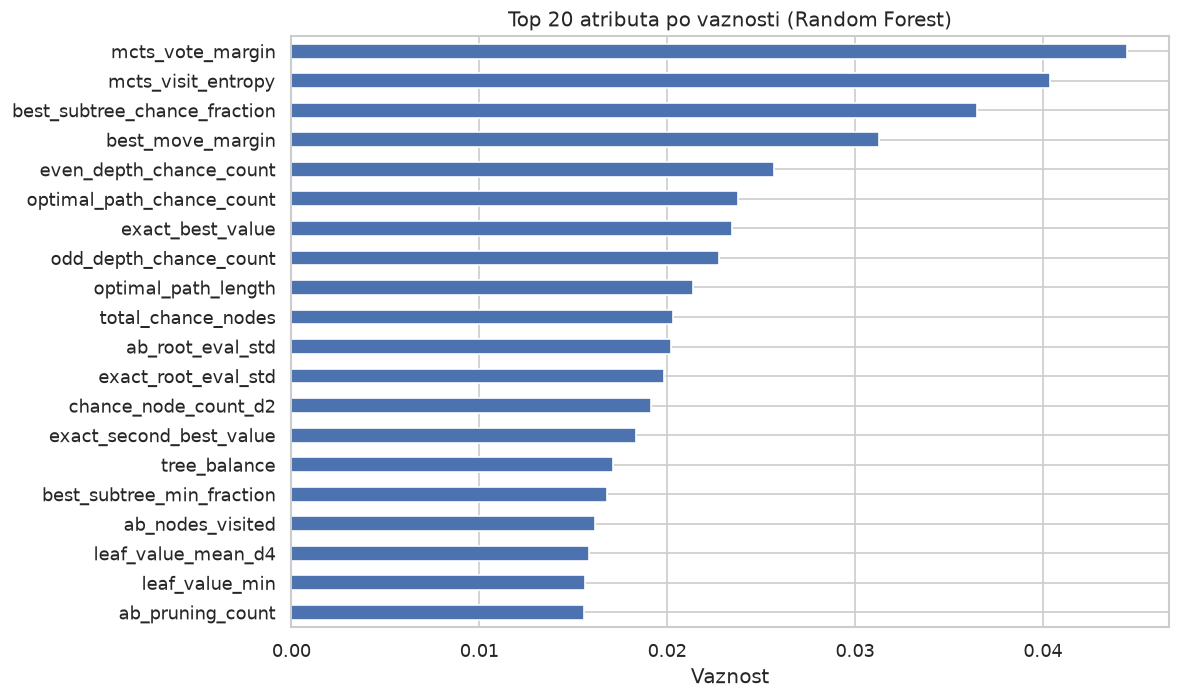

Random Forest (top 39): 39 atributa


In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_vt, y)

importances = pd.Series(rf.feature_importances_, index=feat_after_vt).sort_values(ascending=False)
feat_rf = importances.head(len(feat_after_vt) // 2).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
importances.head(20).sort_values().plot.barh(ax=ax, color=POS_COLOR)
ax.set_title("Top 20 atributa po vaznosti (Random Forest)", fontsize=12)
ax.set_xlabel("Vaznost")
plt.tight_layout()
plt.savefig("../plots/preprocessing/rf_importance.png", bbox_inches="tight")
plt.show()
print(f"Random Forest (top {len(feat_after_vt) // 2}): {len(feat_rf)} atributa")

### 6.4 Presek metoda

Ensemble feature selection: svaka grupa daje jedan glas, atribut ulazi u finalni skup ako ga izaberu bar 2 od 3 grupe (filter, wrapper, embedded). Ovaj pristup je dokumentovan u literaturi (Chen et al., *Expert Systems*, 2020) i u praksi (Xverse biblioteka koristi isti princip sa `minimum_votes`)

Prag 2 od 3 je kompromis: zahtevati sve 3 grupe (presek) je previše konzervativno i gubi dobre atribute, prihvatiti 1 od 3 (unija) je previše liberalno i zadržava šum

In [16]:
all_selected = feat_anova + feat_rfe + feat_rf # konkatanacija lista (sadržaće duplikate što i želimo)
counts = Counter(all_selected)
feat_final = sorted(f for f, cnt in counts.items() if cnt >= 2)

print(f"Finalni skup (>= 2 od 3 grupe): {len(feat_final)} atributa")

pd.DataFrame({
    "ANOVA (filter)": [f in feat_anova for f in feat_final],
    "RFE (wrapper)": [f in feat_rfe for f in feat_final],
    "RF (embedded)": [f in feat_rf for f in feat_final],
    "ukupno glasova": [counts[f] for f in feat_final]
}, index=feat_final)

Finalni skup (>= 2 od 3 grupe): 36 atributa


,ANOVA (filter),RFE (wrapper),RF (embedded),ukupno glasova
ab_nodes_visited,False,True,True,2
ab_pruning_count,True,True,True,3
ab_root_eval_std,False,True,True,2
best_move_margin,True,True,True,3
best_subtree_chance_fraction,True,True,True,3
best_subtree_min_fraction,True,True,True,3
chance_node_count_d1,True,True,False,2
chance_node_count_d2,True,True,True,3
chance_node_count_d3,True,True,True,3
chance_node_count_d9,True,True,False,2


Finalni pretprocesirani skup za klasifikaciju (03_classification.ipynb)

In [17]:
target_cols = ["which_algo", "which_algo_enc", "ab_correct", "mcts_correct",
               "is_contested", "margin_category", "margin_category_enc",
               "tree_difficulty", "tree_difficulty_enc"]
save_cols = feat_final + [c for c in target_cols if c in df.columns]

df[save_cols].to_csv("../data/trees_preprocessed.csv", index=False)
print(f"Sacuvano: {len(df)} slogova, {len(feat_final)} atributa + {len(target_cols)} ciljnih kolona")

Sacuvano: 5016 slogova, 36 atributa + 9 ciljnih kolona
